# Basic comparsion of naive and fast convolution

In [1]:
import numpy as np
import sympy as sy
from PIL import Image
from scipy import signal
from scipy import datasets
from matplotlib import pyplot as plt

In [2]:
from naive_convolve import naive_convolve
from fast_convolution import toom_cook_conv_1d
from utils import plot_pdf, symmetrical_cyclic_convolution

import fast_convolution as fast

In [3]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

Lets do a really basic test to compare naive with fast convolution
The input feature will be a simple 5x5 matrix and the output will be a 3x3 matrix

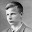

In [4]:
image = Image.open('images/karatsuba032.jpg')
image

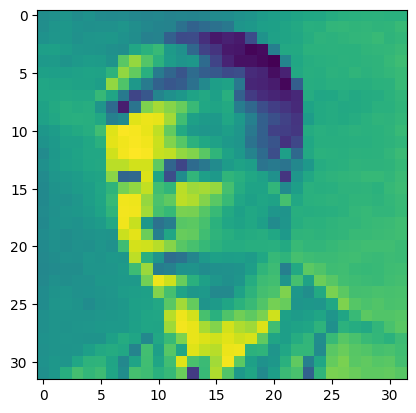

In [123]:
plt.imshow(image)

In [5]:
feature = np.array(image)
feature.shape

In [6]:
# Laplace discrete operator
weight = = np.array([
    [ 0, 1, 0],
    [ 1, -4, 1],
    [ 0, 1, 0],
])
w

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

Convolution with no paddin and stride 1
Using convolve2d from scipy, our gold method, it's necessary to reverse the weights to get same result of naive and fast convolution

In [7]:
wr = weight[::-1, ::-1]
wr

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

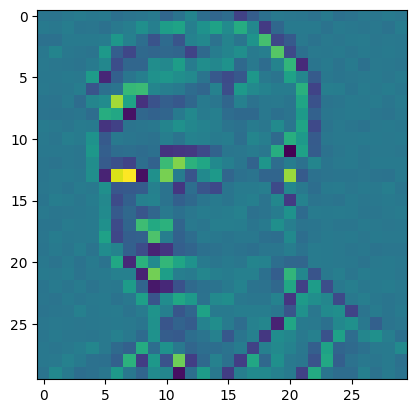

In [8]:
output = signal.convolve2d(feature, wr, mode='valid')
plt.imshow(output)

Running naive convolution
9 multiplications and 8 aditions per output scalar

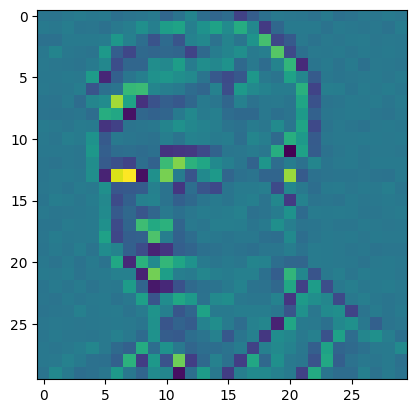

In [9]:
output_naive = naive_convolve(feature, weight)
plt.imshow(output_naive)

In [10]:
np.all(output == output_naive)

True

Fast convolution need to reverse the features order

Init Tap filter from fast 1d convolution method with 5 multiplications, 20 aditions and 9 extras operations, 5 input and 3 output per batch

In [12]:
fast_conv = toom_cook_conv_1d(3, 3, [0, -1, 1, -2, np.inf], w[0])

The tap filter work in batch mode and the output is reversed

In [112]:
c0 = np.convolve(feature[0], weight[0], mode='valid')
c0

array([120, 124, 118, 122, 116, 115, 116, 111, 109, 111, 107, 109, 108,
       110, 116, 117, 121, 124, 132, 135, 136, 140, 143, 144, 148, 151,
       152, 153, 154, 152])

In [113]:
c1 = np.convolve(feature[1], weight[1], mode='valid')
c1

array([-254, -261, -241, -237, -243, -238, -260, -239, -221, -213, -230,
       -177, -130, -170, -180, -169, -276, -252, -276, -269, -279, -289,
       -309, -291, -323, -321, -311, -319, -309, -311])

In [114]:
c2 = np.convolve(feature[2], weight[2], mode='valid')
c2

array([126, 127, 121, 125, 126, 127, 122, 118, 106, 107,  74,  55,  56,
        33,  16,  23,  18,  57, 123, 137, 140, 144, 149, 155, 154, 156,
       158, 159, 161, 156])

In [120]:
fast_conv = [toom_cook_conv_1d(3, 3, [0, -1, 1, -2, np.inf], weight[i]) for i in range(3)]

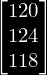

In [228]:
out0 = fast_conv[0](feature[0, :5])
out0

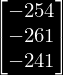

In [229]:
out1 = fast_conv[1](feature[1, :5])
out1

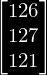

In [231]:
out2 = fast_conv[2](feature[2, :5])
out2

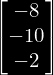

In [232]:
out0 + out1 + out2

In [106]:
output[0, :3]

array([ -8, -10,  -2])

In [76]:
pad = 0


How join multiple 1d convolution in one 2d convolution

Sum results in the first dimension

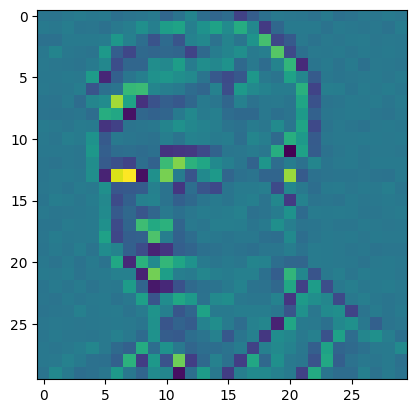

In [202]:
output_fast = np.sum([fast.filter1d_slide2d(fast_conv[i], feature, output.shape, i) for i in range(0, 3)], axis=0)
plt.imshow(output_fast)

In [227]:
np.all(output_fast == output_naive).

True

Camparing how much operations are used in naive and fast method

Output Size

In [206]:
size = output.size
size

Naive: total of multiplications

In [25]:
size * 9

Naive: total of additions

In [26]:
size * 8

Fast: total of multiplications

In [222]:
fast_op_count = fast.filter1d_slide2d_count(output.shape)
fast_op_count * 5 * len(fast_conv)

Fast: additions for each batch processed

In [226]:
add0 =fast_op_count * 20 * len(fast_conv)
add0

Fast: additions to join batches

In [225]:
add1 = fast_op_count * 2 * len(fast_conv)
add1

Fast: Total of additions

In [220]:
add0 + add1

Fast: total of extra operations - bit shifts and etc

In [224]:
fast_op_count * 9 * len(fast_conv)